In [1]:
from datetime import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import time
import re
from bootstrap_mc_kalshi import load_and_prepare, build_player_pool, build_player_pool_score, run_simulation, run_simulation_score, build_results, USERNAME_TO_PLAYER, PLAYER_TO_USERNAME

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option({
    'display.max_rows':300,
    'display.max_columns':300,
    'display.max_colwidth':300
})

# df_tourneys = pd.read_csv("data/titled_tuesday_tournaments.csv")
# df_standings = pd.read_csv("data/titled_tuesday_standings.csv")
# df_tourneys = df_tourneys[df_tourneys["date"]>"2022-02-01"]
# df_standings = df_standings[df_standings["date"]>"2022-02-01"]

# df_standings.head()
# CUT_PLAYERS = ['Matthias Bluebaum','Levon Aronian','Yagiz Kaan Erdogmus','Jose Martinez','Le Quang Liem', 'Daniel Naroditsky']
# KEEP_PLAYERS = []
# N_SIMS = 10_000


# df, p_participate, app_counts = load_and_prepare(CUT_PLAYERS, KEEP_PLAYERS, attendance_model='decay')
# players, p_play, hist_pcts, hist_wts = build_player_pool_score(
#     df, p_participate, app_counts, min_appearances=5
# )

# print(f'Pool: {len(players):,} players | simulating {N_SIMS:,} tournaments...')
# # plays_ct, topn_ct = run_simulation_score(players, p_play, hist_pcts, hist_wts, n_sims = N_SIMS)
# # results = build_results(players, p_play, plays_ct, topn_ct, n_sims= N_SIMS)
# # results.to_csv("data/model_predictions_07_21_2026.csv")
# display(players)

results = pd.read_csv("data/model_predictions/latest.csv")

In [2]:
BASE = "https://api.elections.kalshi.com/trade-api/v2"
event_tickers = ["KXTITLEDTUESDAY-26JUL21","KXTITLEDTUESTOP-26JUL21T3","KXTITLEDTUESTOP-26JUL21T8"]


markets = []
cursor = None
for event_ticker in event_tickers:
    while True:
        params = {"event_ticker": event_ticker, "status": "open", "limit": 200}
        if cursor:
            params["cursor"] = cursor
        resp = requests.get(f"{BASE}/markets", params=params)
        resp.raise_for_status()
        data = resp.json()
        markets.extend(data.get("markets", []))
        cursor = data.get("cursor")
        if not cursor:
            break

all_asks= []

if markets:
    print(f"Found {len(markets)} markets in events '{[event_ticker for event_ticker in event_tickers]}'. Fetching rates...")

    for market in markets:
        ticker = market["ticker"]
        title = market.get("title", "")
        subtitle = market.get("yes_sub_title", "")

        ob_resp = requests.get(f"{BASE}/markets/{ticker}/orderbook")

        if ob_resp.status_code == 200:
            ob = ob_resp.json().get("orderbook_fp") or {}
            # Resting NO bids: each [price, qty] NO bid implies
            # YES is for sale at (1.00 - no_price) for that quantity.
            yes_levels = ob.get("yes_dollars") or []
            no_levels = ob.get("no_dollars") or []

            for price_str, qty_str in yes_levels:
                no_ask = float("1.00") - float(price_str)
                all_asks.append({
                    "Market Ticker": ticker,
                    "Market Title": title,
                    "Player Name": subtitle,
                    "Ask Price ($)": float(no_ask),
                    "Quantity Available": float(qty_str),
                    "Side": "NO"
                })
            for price_str, qty_str in no_levels:
                yes_ask = float("1.00") - float(price_str)
                all_asks.append({
                    "Market Ticker": ticker,
                    "Market Title": title,
                    "Player Name": subtitle,
                    "Ask Price ($)": float(yes_ask),
                    "Quantity Available": float(qty_str),
                    "Side": "YES"
                })
        else:
            print(f"Could not retrieve orderbook for {ticker} "
                  f"(HTTP {ob_resp.status_code})")

        time.sleep(0.05)  # stay under public rate limits


def kalshi_order_price(ask_price):
    return ask_price + (0.07 * ask_price * (1.0 - ask_price))

Found 156 markets in events '['KXTITLEDTUESDAY-26JUL21', 'KXTITLEDTUESTOP-26JUL21T3', 'KXTITLEDTUESTOP-26JUL21T8']'. Fetching rates...


In [3]:
results = pd.read_csv("data/model_predictions/latest.csv").set_index('username')
df = pd.DataFrame(all_asks)
df['n'] = df['Market Title'].apply(lambda s: re.search(r'\d+',s).group())

df['username'] = df['Player Name'].apply(lambda n: PLAYER_TO_USERNAME[n])
evs = []
order_prices=[]
for _, row in df.iterrows():
    n = 1 if row['n'] == '21' else int(row['n'])
    p_yes = (results.loc[row['username'], f'P_top{n}'].item())
    evs.append(p_yes if row['Side']=='YES' else (1-p_yes))

df['EV'] = evs
df['Order Price'] = (df['Ask Price ($)'] + 0.07 * df['Ask Price ($)'] * (1.0 - df['Ask Price ($)']))
df['Total Cost'] = df['Quantity Available']*df['Order Price']
df['Expected Return'] = ((df['EV']-df['Order Price'])*df['Quantity Available'].astype(int))
df['ROI'] = round(df['EV']/df['Order Price'].astype(float),3)
df = df[df['ROI']>1.]
print(df['Expected Return'].sum())
df[['Market Title','ROI','Side','Order Price','EV','Quantity Available','Total Cost','Expected Return']][(df['ROI']>1.)].sort_values('ROI',ascending=False)

693.8826690000001


,Market Title,ROI,Side,Order Price,EV,Quantity Available,Total Cost,Expected Return
861,"Will Aleksei Sarana finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.533,YES,0.137917,0.21149,111.00,15.308787,8.166603
565,"Will Sina Movahed finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.432,YES,0.106300,0.15220,177.00,18.815100,8.124300
860,"Will Aleksei Sarana finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.425,YES,0.148428,0.21149,100.00,14.842800,6.306200
801,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.381,YES,0.158925,0.21951,300.00,47.677500,18.175500
1296,"Will Dincer Tasdogen finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",1.378,YES,0.085152,0.11736,116.00,9.877632,3.736128
1018,"Will Renato Terry Lujan finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",1.333,YES,0.127392,0.16977,100.00,12.739200,4.237800
859,"Will Aleksei Sarana finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.331,YES,0.158925,0.21149,200.00,31.785000,10.513000
1306,"Will Denis Lazavik finish top 8 in the Titled Tuesday chess competition on Jul 21, 2026?",1.308,YES,0.304413,0.39824,112.00,34.094256,10.508624
564,"Will Sina Movahed finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.302,YES,0.116853,0.15220,100.00,11.685300,3.534700
800,"Will Denis Lazavik finish top 3 in the Titled Tuesday chess competition on Jul 21, 2026?",1.296,YES,0.169408,0.21951,200.00,33.881600,10.020400


In [ ]:
# ── Simple (single-bet) Kelly sizing ─────────────────────────────────────────
# f* = (p - c) / (1 - c)  where p = model probability, c = cost per share
# Applied independently per position then normalised if total > 1.
# Use KELLY_MULT < 1 (half-Kelly = 0.5 recommended) to account for model error.

BANKROLL   = 2000   # <-- set to your actual bankroll in $
KELLY_MULT = 0.5    # half-Kelly

df_pos = df[df['ROI'] > 1.0].copy()

# Raw single-bet Kelly fraction: optimal bankroll fraction if this were the only bet
df_pos['kelly_f'] = (df_pos['EV'] - df_pos['Order Price']) / (1.0 - df_pos['Order Price'])

# If the sum of independent Kelly fractions exceeds 1, the positions collectively
# need more than the full bankroll.  Normalise proportionally as a conservative
# approximation for correlated simultaneous bets.
total_f = df_pos['kelly_f'].sum()
if total_f > 1.0:
    print(f"Sum of single-bet Kelly fractions = {total_f:.2f} — normalising to 1.0")
    df_pos['kelly_f'] /= total_f

# alloc_frac: final fraction of bankroll deployed to each position
# = normalised kelly_f * KELLY_MULT
df_pos['alloc_frac']   = df_pos['kelly_f'] * KELLY_MULT
df_pos['kelly_shares'] = (df_pos['alloc_frac'] * BANKROLL / df_pos['Order Price']).round().clip(lower=0).astype(int)
df_pos['kelly_cost']   = df_pos['kelly_shares'] * df_pos['Order Price']
df_pos['kelly_ev']     = df_pos['kelly_shares'] * df_pos['EV']
df_pos['kelly_edge']   = df_pos['kelly_ev'] - df_pos['kelly_cost']

df_kelly = df_pos[df_pos['kelly_shares'] > 0].copy()

total_cost = df_kelly['kelly_cost'].sum()
total_ev   = df_kelly['kelly_ev'].sum()
print(f"Bankroll ${BANKROLL:,.0f}  |  Exposure ${total_cost:.0f} ({total_cost/BANKROLL*100:.1f}%)  |  "
      f"Expected edge ${total_ev - total_cost:.2f}  |  Portfolio ROI {(total_ev/total_cost - 1)*100:.1f}%\n")

df_kelly[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'kelly_f', 'alloc_frac', 'kelly_shares', 'kelly_cost', 'kelly_edge']]\
    .sort_values('kelly_f', ascending=False)\
    .style.format({'Order Price': '{:.3f}', 'EV': '{:.3f}', 'kelly_f': '{:.4f}', 'alloc_frac': '{:.4f}',
                   'kelly_cost': '${:.2f}', 'kelly_edge': '${:.2f}'})

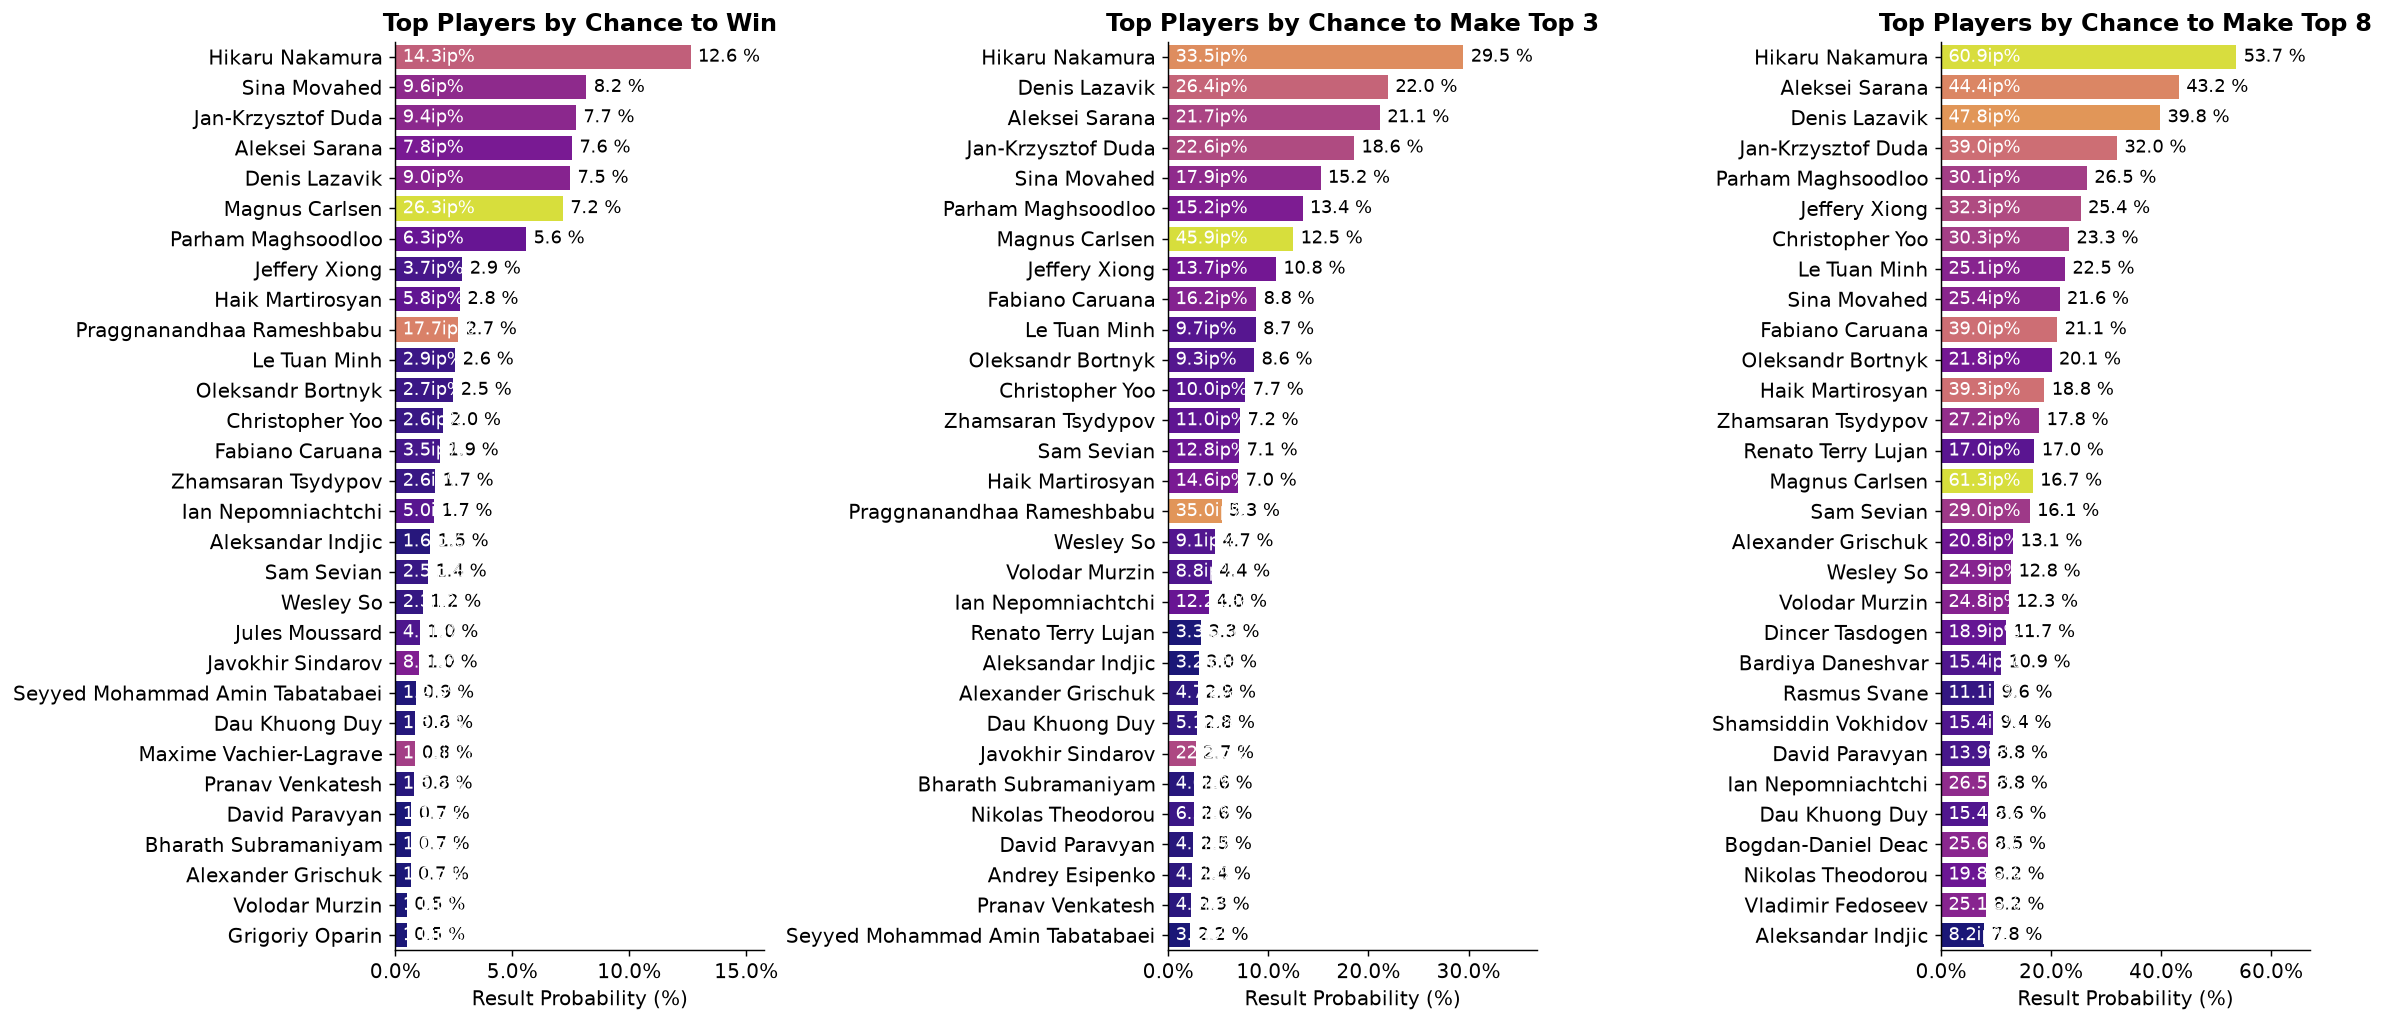

In [4]:
fig, axes = plt.subplots(1,3, figsize=(18,8))

metrics = [
    (1,'Top Players by Chance to Win'),
    (3,'Top Players by Chance to Make Top 3'),
    (8,'Top Players by Chance to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_chance = f'P_top{n}'
    col_when = f'P_top{n}_given_play'

    df_plot = results.nlargest(30,col_chance).reset_index()

    norm = mcolors.Normalize(vmin=df_plot[col_when].min(), vmax=df_plot[col_when].max())
    colors = cmap(norm(df_plot[col_when]))

    names = [USERNAME_TO_PLAYER.get(username,username) for username in df_plot['username']]

    sns.barplot(data = df_plot, x=col_chance, y=names, ax=ax, palette=colors)

    ax.set_title(title, fontweight='bold')

    max_width = df_plot[col_chance].max()*1.25
    ax.set_xlim(0, max_width)
    ax.set_xlabel('Result Probability (%)')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        
        chance_val = df_plot.iloc[i][col_chance]
        when_val = df_plot.iloc[i][col_when]

        ax.text(width + (max_width * 0.02), y, f'{chance_val*100:.1f} %', va = 'center', ha='left', fontsize=10, color='black')
        ax.text(max_width * 0.02, y, f'{when_val*100:.1f}ip%', va = 'center', ha='left', fontsize=10, color='white')

plt.tight_layout()
plt.show()

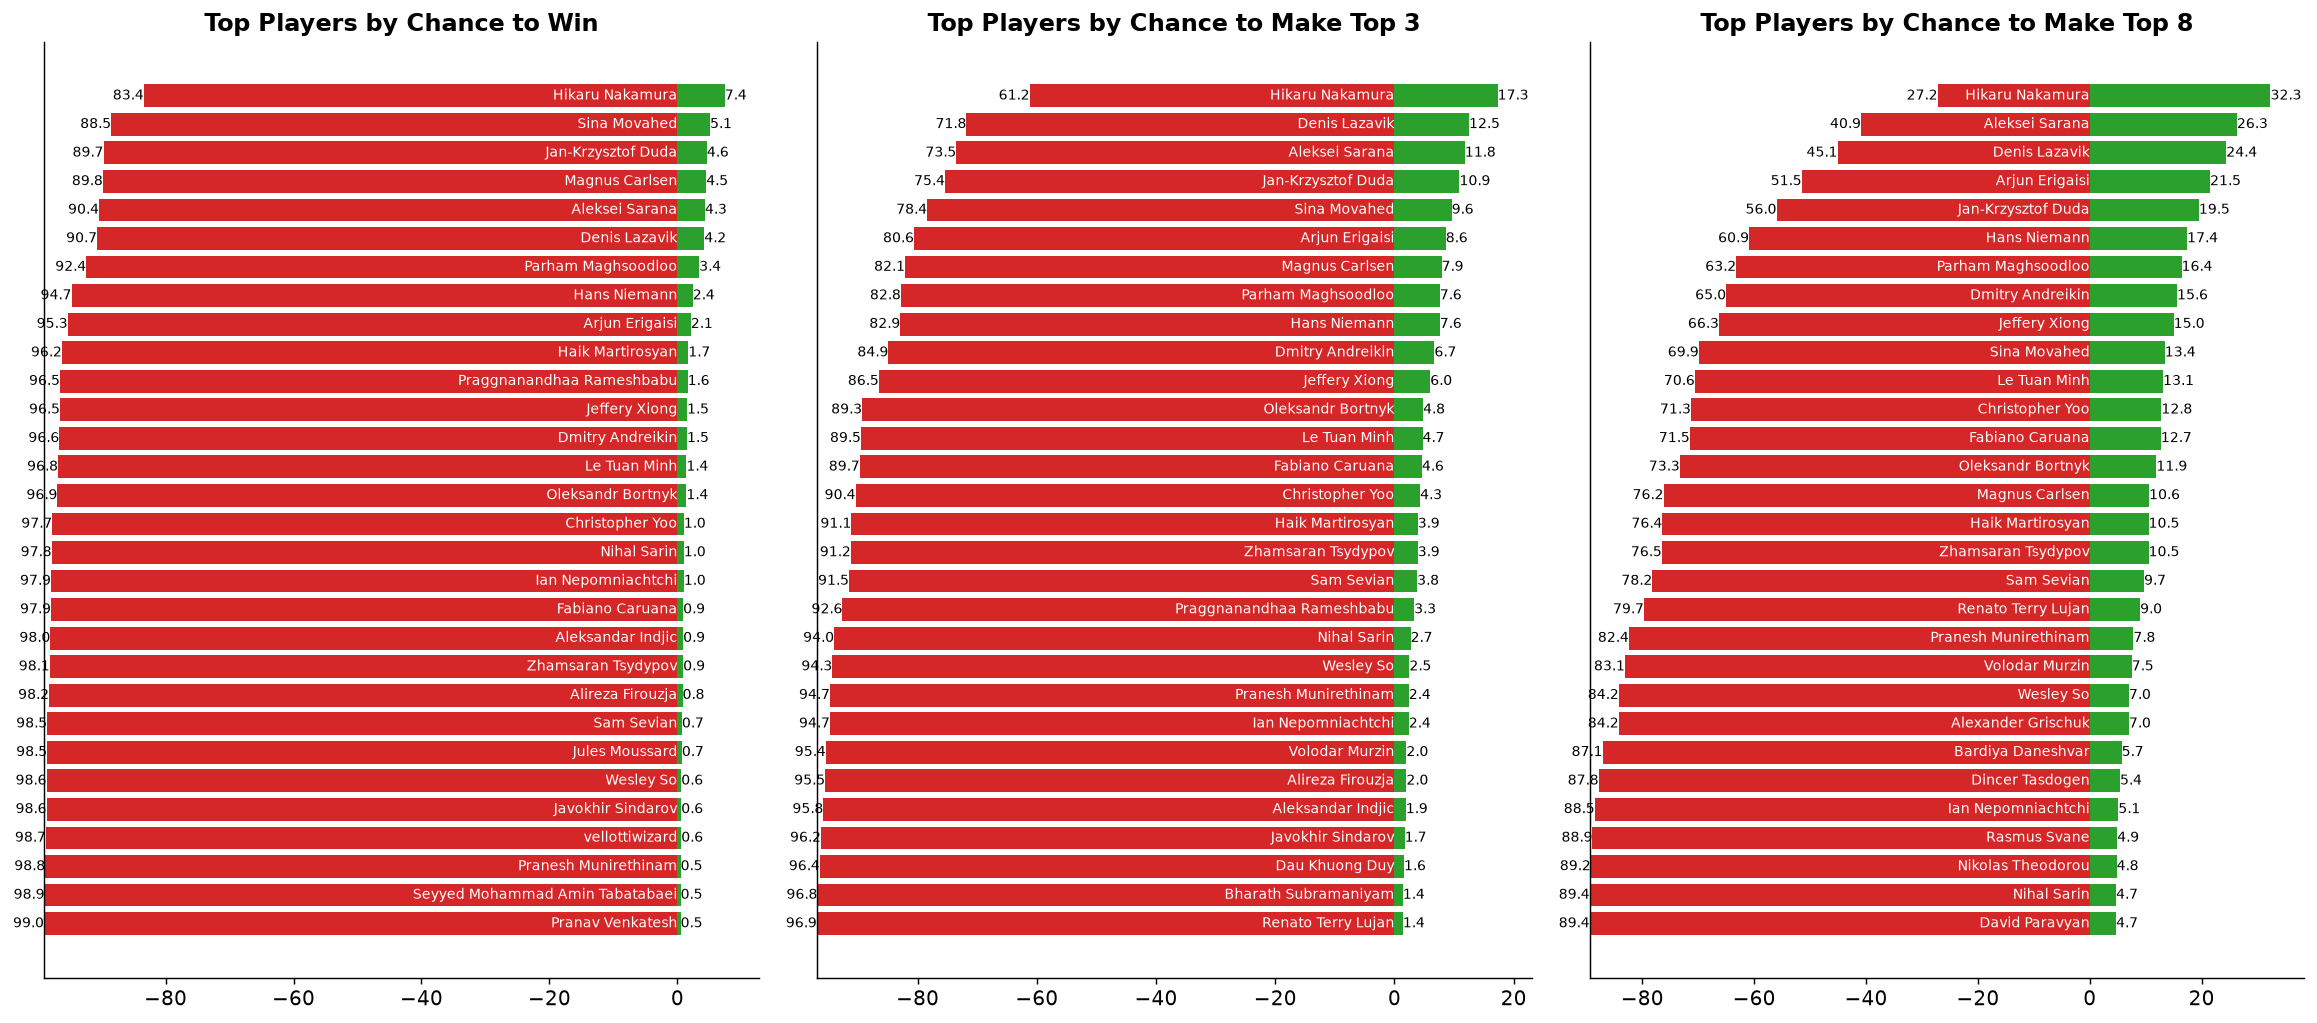

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18,8))

metrics = [
    (1,'Top Players by Chance to Win'),
    (3,'Top Players by Chance to Make Top 3'),
    (8,'Top Players by Chance to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_chance = f'P_top{n}'
    col_when = f'P_top{n}_given_play'

    df_plot = results.nlargest(30,col_chance).reset_index()

    # Calculate Kalshi Yes and No prices
    # Using np.clip to ensure the No price doesn't drop below $0.00 if the estimate is very high (>75%)
    df_plot['Yes_Price'] = np.round(df_plot[col_chance] * (2/3) * 100, 1)
    df_plot['No_Price'] = np.round((1-df_plot[col_chance] * (3/2))*100, 1)

    # --- Plot YES Bars ---
    ax.barh(df_plot.index, df_plot['Yes_Price'], height=0.8, color='#2ca02c', label='Yes Price')

    # --- Plot NO Bars ---
    ax.barh(df_plot.index, df_plot['No_Price'], left=-df_plot['No_Price'], height=0.8, color='#d62728', label='No Price')

    # Set the Y-axis labels to the Yes Price
    ax.set_yticks([])
    ax.invert_yaxis()  # Put the highest chance player at the top
    ax.set_title(title, fontweight='bold')

    
    # Add data labels dynamically
    for i, row in df_plot.iterrows():
        yes_val = row['Yes_Price']
        no_val = row['No_Price']
        name = USERNAME_TO_PLAYER.get(row['username'],row['username'])
        
        # Text for the Yes price (placed slightly to the right of the green bar's edge)
        ax.text(yes_val, i, yes_val, va='center', ha='left', fontsize=8, color='black')
        
        # Text for the No price (placed slightly to the left of the red bar's edge)
        # The inner edge of the red bar is exactly at (1 - no_val)
        ax.text(-no_val, i, no_val, va='center', ha='right', fontsize=8, color='black')

        ax.text(0, i, name, va='center', ha='right', fontsize=8, color='white')



plt.tight_layout()
plt.show()

Sanan_Sjugirov ?
Durarbayli ?
Cayse ?


findfont: Failed to find font weight heavy, now using 700.


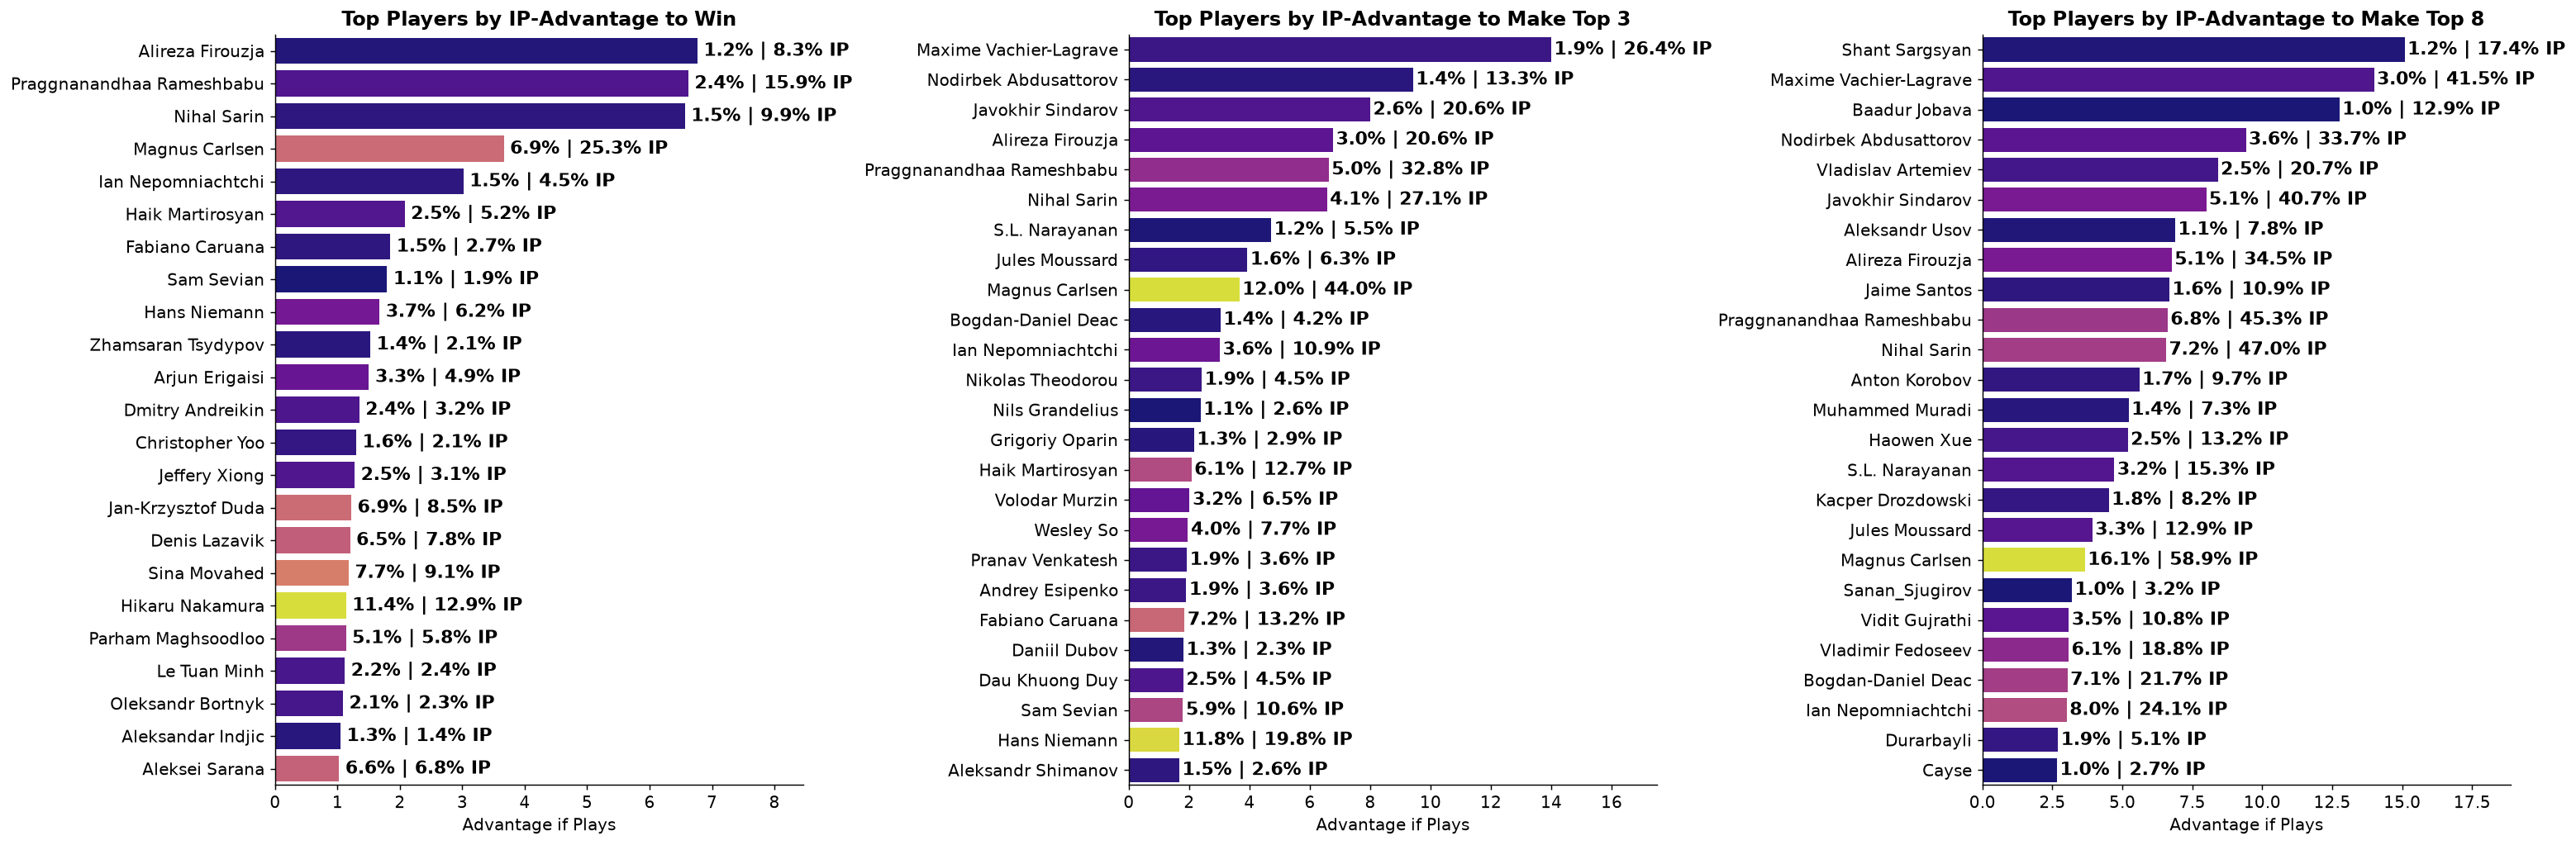

In [36]:
fig, axes = plt.subplots(1,3, figsize=(24,8))

metrics = [
    (1,'Top Players by IP-Advantage to Win'),
    (3,'Top Players by IP-Advantage to Make Top 3'),
    (8,'Top Players by IP-Advantage to Make Top 8'),
]

cmap = plt.get_cmap('plasma')

for ax, (n, title) in zip(axes, metrics):

    col_when = f'P_top{n}'
    col_chance = f'P_top{n}_given_play'
    ip_adv = f'ip_adv_top{n}'

    df_plot = results[results[col_when]>.01].nlargest(25,ip_adv).reset_index()

    def get_name(username):
        try:
            return USERNAME_TO_PLAYER[username]
        except:
            print(username, "?")
            return username
    df_plot['name'] = df_plot['username'].apply(get_name)

    norm = mcolors.Normalize(vmin=df_plot[col_when].min(), vmax=df_plot[col_when].max())
    colors = cmap(norm(df_plot[col_when]))

    sns.barplot(data = df_plot, x=ip_adv, y='name', ax=ax, palette=colors)

    ax.set_title(title, fontweight='bold')

    max_width = df_plot[ip_adv].max()*1.25
    ax.set_xlim(0, max_width)
    ax.set_xlabel('Advantage if Plays')
    ax.set_ylabel('')

    for i, p in enumerate(ax.patches):
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        
        chance_val = df_plot.iloc[i][col_chance]
        when_val = df_plot.iloc[i][col_when]
        adv_val = df_plot.iloc[i][ip_adv]
        name = df_plot.iloc[i]['name']

        ax.text(adv_val+0.1, y, f'{when_val*100:.1f}% | {chance_val*100:.1f}% IP', va = 'center', ha='left', fontsize=12, color='black', fontweight='heavy')

plt.tight_layout()
plt.show()

In [5]:
def display_profits(df_tt, df_results, verbose=False):
    costs = 0
    revenue = 0
    for idx, row in df_tt.iterrows():
        costs += row['cost']

        pos = 1.0 if row['position']=='Yes' else 0.0
        username = PLAYER_TO_USERNAME[row['marketTitle']][0]
        n = row['n']

        if not username in df_results.index:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. -${row['cost']}")
            continue

        result = df_results.loc[username, f'P_top{n}'].item()

        if result == pos:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. +${row['volume'] - row['cost']}")
            revenue += row['volume']
        else:
            if verbose:
                print(f"{row['marketTitle']} in top {n}: {'YES' if result > 0 else 'NO'}. -${row['cost']}")
            pass
    
    return revenue - costs

def avg_profits(df, df_results, fees=0, verbose=False):
    revenues = []
    costs = []
    values = []
    values_per_share = []
    for idx, row in df.iterrows():
        username = PLAYER_TO_USERNAME[row['marketTitle']]
        n = row['n']
        costs.append(round(row['volume']*row['orderPrice'],2))

        if not username in df_results.index:
            print(f"{row['marketTitle']} in top {n}\t\t{row['position'].upper()}:\tBought {row['volume']} @{row['orderPrice']:.2f}.\t0.0 EV per share.\t ${-row['cost']:.2f} EV\t {0:.2f}% ROI")
            revenues.append(0)
            continue

        result = df_results.loc[username, f'P_top{n}'].item()
        value = result if row['position']=='Yes' else (1-result)
        revenues.append(row['volume']*value)
        values.append(f'${value*row['volume']:.2f}')
        values_per_share.append(value)
        if verbose:
            print(f"{row['marketTitle']} in top {n}\t\t{row['position'].upper()}:\tBought {row['volume']} @{row['orderPrice']:.2f}.\t{value:.2f} EV per share.\t ${row['volume']*value-row['cost']:.2f} EV\t {(row['volume']*value/row['cost']-1)*100:.2f}% ROI")

    # Calculate ROI, EV for each position

    expected_return_col = [round(r-c,2) for r,c in zip(revenues, costs)]
    roi_col = [round(r/c,2) for r,c in zip(revenues, costs)]

    # Calculate Summary Statistics
    revenue = sum(revenues)
    cost = sum(costs)+fees
    net_profit = revenue-cost
    roi = (revenue/cost-1)*100

    print(f"Total Exposure:{cost}. Expected Revenue: {revenue}. Net profits avg: {net_profit:.2f}. ROI {roi:.2f}%")

    return expected_return_col, values, values_per_share, roi_col, costs

n_title_dict = {
    'Titled Tuesday Top 8: Jul 21': 8,
    'Titled Tuesday Top 3: Jul 21': 3,
    'Titled Tuesday Winner: Jul 21': 1
    }

# Building the Kalshi Portfolio DF
kalshi_orders = pd.read_csv("data/Kalshi-Advanced-Portfolio.csv")
df_tt = kalshi_orders[kalshi_orders['eventTitle'].str.contains('Tuesday')]
df_tt[['position','volume']] = df_tt['position'].str.split(' x ',expand=True)
df_tt['volume'] = df_tt['volume'].astype(float)
df_tt['n'] = df_tt['eventTitle'].apply(lambda x: n_title_dict[x])
df_tt['orderPrice'] = kalshi_order_price(df_tt['averagePrice'].str.extract('(\d+)').astype(float)/100.0)
df_tt['expectedReturn'], df_tt['expectedValue'], df_tt['evPerShare'], df_tt['ROI'], df_tt['cost']=avg_profits(df_tt, results)
df_tt['eventTitle'] = df_tt['eventTitle'].apply(lambda event: f'Top {n_title_dict[event]}')
df_tt[['eventTitle','marketTitle','position','ROI','averagePrice','orderPrice','evPerShare','cost','expectedValue','expectedReturn']].sort_values('ROI',ascending=False)

Total Exposure:1519.64. Expected Revenue: 1474.10403. Net profits avg: -45.54. ROI -3.00%


,eventTitle,marketTitle,position,ROI,averagePrice,orderPrice,evPerShare,cost,expectedValue,expectedReturn
53,Top 1,Sina Movahed,Yes,1.53,5¢,0.053325,0.08167,5.33,$8.17,2.84
40,Top 3,Jan-Krzysztof Duda,Yes,1.46,12¢,0.127392,0.18569,38.85,$56.64,17.79
31,Top 8,Renato Terry Lujan,Yes,1.45,11¢,0.116853,0.16977,12.39,$18.00,5.61
43,Top 3,Sina Movahed,Yes,1.43,10¢,0.106300,0.15220,58.68,$84.01,25.33
17,Top 8,Aleksei Sarana,Yes,1.42,29¢,0.304413,0.43237,93.15,$132.31,39.16
35,Top 3,Aleksei Sarana,Yes,1.42,14¢,0.148428,0.21149,64.42,$91.79,27.37
36,Top 3,Denis Lazavik,Yes,1.38,15¢,0.158925,0.21951,27.18,$37.54,10.36
24,Top 8,Jan-Krzysztof Duda,Yes,1.38,22¢,0.232012,0.31991,72.16,$99.49,27.33
21,Top 8,Haik Martirosyan,Yes,1.36,13¢,0.137917,0.18792,41.51,$56.56,15.05
30,Top 8,Parham Maghsoodloo,Yes,1.32,19¢,0.200773,0.26524,61.24,$80.90,19.66


  p_participate: decay-weighted EWMA with Isotonic Gaussian participation floor (@p < .05)
  231 events | 8,840 unique players | 2022-02-08 to 2026-07-14
  Player pool: 8,840
   10,000 / 20,000  (5.0s)
   20,000 / 20,000  (10.3s)

── Portfolio (20,000 simulated tournaments) ──────────────
  Mean        : $+253.79
  Std dev     : $535.24
  5th pctile  : $-628.60
  25th pctile : $-125.60
  Median      : $+210.40
  75th pctile : $+621.40
  95th pctile : $+1182.45
  Worst case  : $-932.60
  Best case   : $+2459.40


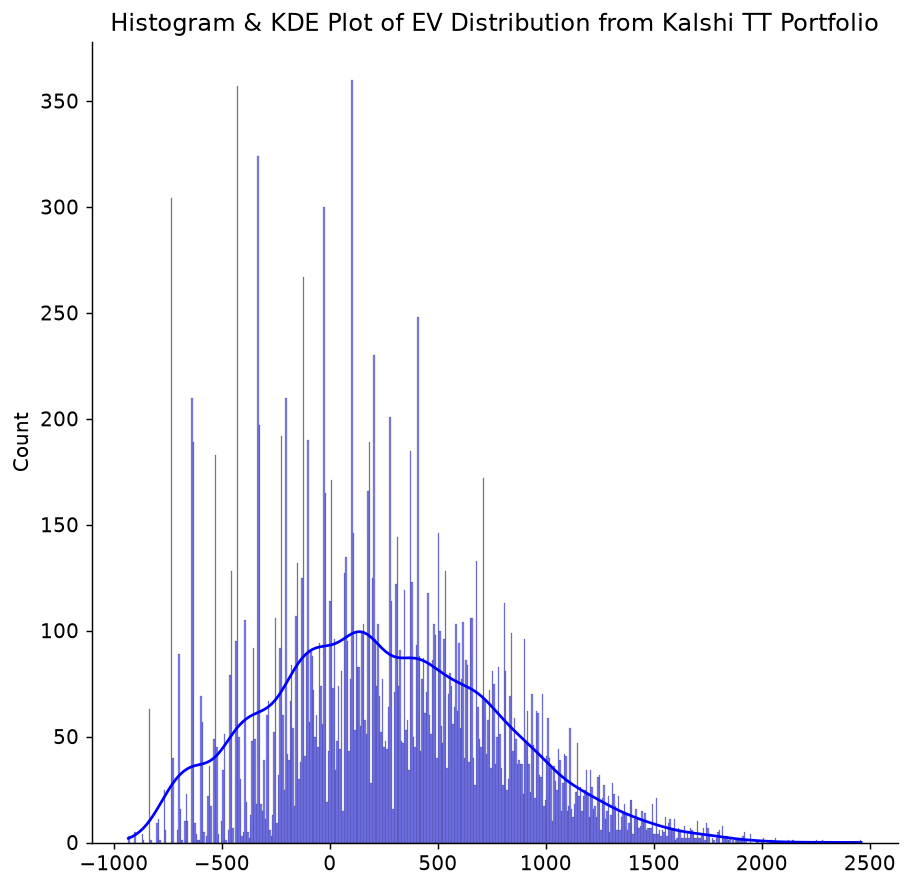

In [23]:
from bootstrap_mc_kalshi import (
    load_and_prepare, build_player_pool,
    build_portfolio, run_portfolio_mc, pnl_summary,
)

df, p_participate, app_counts = load_and_prepare(
    cut_players=['Matthias Bluebaum','Levon Aronian','Yagiz Kaan Erdogmus','Jose Martinez','Le Quang Liem', 'Daniel Naroditsky'],
    attendance_model='decay'
)
players, p_play, hist_pcts, hist_wts = build_player_pool(df, p_participate, app_counts)
portfolio = build_portfolio(df_tt, players, PLAYER_TO_USERNAME)
pnl = run_portfolio_mc(players, p_play, hist_pcts, hist_wts, portfolio, n_sims=20_000)
pnl_summary(pnl)


fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        
sns.histplot(x=pnl, kde=True, ax=ax, color='blue', bins=500)

ax.set_title('Histogram & KDE Plot of EV Distribution from Kalshi TT Portfolio')

plt.show()
plt.close(fig)

In [ ]:
# ── Portfolio Kelly optimisation (MC-based) ───────────────────────────────────
# Maximises E[log(bankroll + PnL)] over share counts, accounting for the
# correlation structure of chess outcomes discovered by the simulation.
# This is strictly better than simple Kelly when bets are correlated.

from bootstrap_mc_kalshi import run_payoff_matrix, portfolio_kelly

# Build a 1-share-per-position portfolio from every positive-EV orderbook entry.
# run_payoff_matrix returns the per-share payoff, so the optimizer works in
# share units and the cost constraint keeps total exposure <= kelly_fraction * bankroll.
df_cands = df[df['ROI'] > 1.0].copy()
df_cands['n_int'] = df_cands['n'].apply(lambda x: 1 if str(x) == '21' else int(x))

# Drop the original string 'n' column before renaming n_int -> n to avoid
# duplicate column names (which cause port_n to be 2D in build_portfolio).
df_cands_fmt = (
    df_cands
    .drop(columns=['n'])
    .rename(columns={'Player Name': 'marketTitle', 'Side': 'position', 'n_int': 'n'})
    .copy()
)
df_cands_fmt['position'] = df_cands_fmt['position'].str.title()   # YES -> Yes, NO -> No
df_cands_fmt['volume']   = 1.0                                      # 1 share = unit for payoff matrix
df_cands_fmt['cost']     = df_cands_fmt['Order Price']             # cost per share

portfolio_cands = build_portfolio(df_cands_fmt, players, PLAYER_TO_USERNAME)

print("Running payoff matrix simulation (50k sims)...")
payoff_matrix, cost_per_share = run_payoff_matrix(
    players, p_play, hist_pcts, hist_wts,
    portfolio_cands, n_sims=50_000,
)

print("\nOptimising Kelly allocation...")
opt_shares, opt_result = portfolio_kelly(
    payoff_matrix, cost_per_share,
    bankroll=BANKROLL, kelly_fraction=KELLY_MULT,
)

df_cands['opt_shares'] = opt_shares
df_cands['opt_cost']   = opt_shares * df_cands['Order Price']
df_cands['opt_ev']     = opt_shares * df_cands['EV']
df_cands['opt_edge']   = df_cands['opt_ev'] - df_cands['opt_cost']

df_opt = df_cands[df_cands['opt_shares'] > 0].copy()
total_cost_opt = df_opt['opt_cost'].sum()
total_ev_opt   = df_opt['opt_ev'].sum()
print(f"\nPortfolio Kelly  |  Exposure ${total_cost_opt:.0f} ({total_cost_opt/BANKROLL*100:.1f}%)  |  "
      f"Expected edge ${total_ev_opt - total_cost_opt:.2f}  |  ROI {(total_ev_opt/total_cost_opt - 1)*100:.1f}%\n")

df_opt[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'opt_shares', 'opt_cost', 'opt_edge']]\
    .sort_values('opt_shares', ascending=False)\
    .style.format({'Order Price': '{:.3f}', 'EV': '{:.3f}',
                   'opt_cost': '${:.2f}', 'opt_edge': '${:.2f}'})

In [24]:
from bootstrap_mc_kalshi import compute_hedge_correlations, show_best_hedges

df_corr, pnl = compute_hedge_correlations(
    players, p_play, hist_pcts, hist_wts, portfolio,
    n_values=[1, 3, 8], n_sims=100_000,
)

show_best_hedges(df_corr, top_k=20, username_to_player=USERNAME_TO_PLAYER)

   10,000 / 100,000  (5.1s)
   20,000 / 100,000  (10.3s)
   30,000 / 100,000  (15.4s)
   40,000 / 100,000  (20.6s)
   50,000 / 100,000  (26.0s)
   60,000 / 100,000  (31.1s)
   70,000 / 100,000  (36.2s)
   80,000 / 100,000  (41.3s)
   90,000 / 100,000  (46.3s)
  100,000 / 100,000  (51.4s)

── Best YES hedges (negative correlation with portfolio) ────────
                         player  n  P(top N)  corr(YES, portfolio)
                Hikaru Nakamura  3    0.2672               -0.1475
                Hikaru Nakamura  8    0.4857               -0.1160
                Hikaru Nakamura  1    0.1063               -0.1134
Seyyed Mohammad Amin Tabatabaei  8    0.0663               -0.1024
              Javokhir Sindarov  8    0.0512               -0.0904
                   Le Tuan Minh  3    0.0690               -0.0895
                Fabiano Caruana  3    0.0776               -0.0887
              Javokhir Sindarov  3    0.0284               -0.0838
                Christopher Yoo  3    0.0

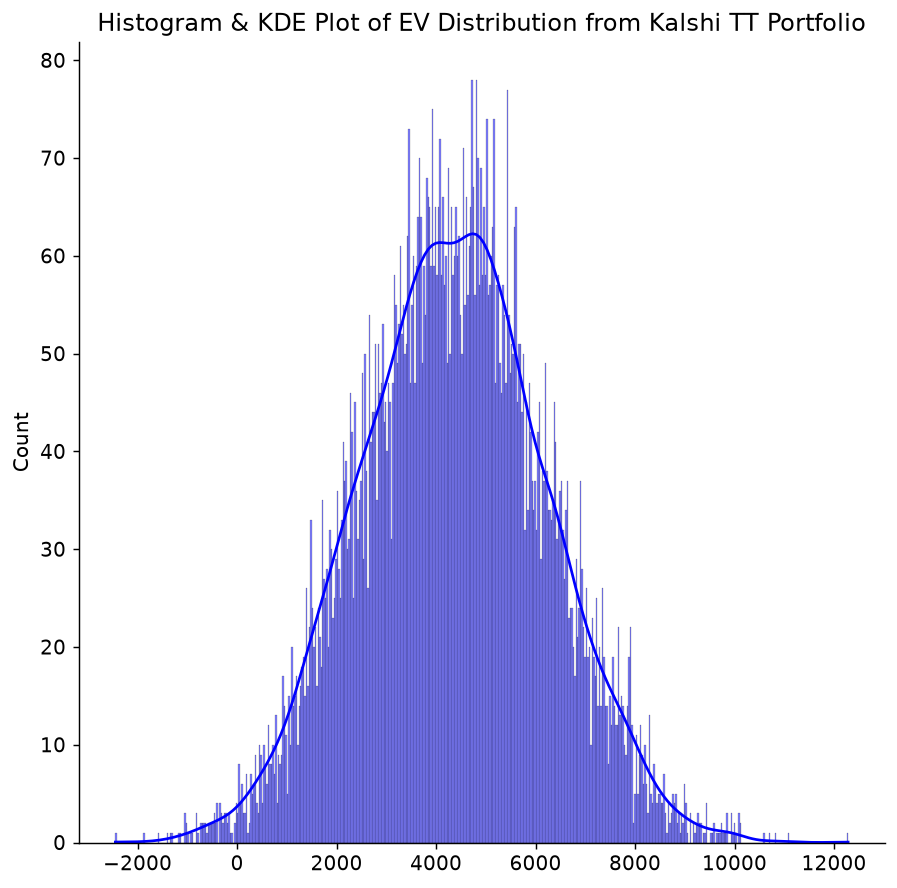

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        
sns.histplot(x=[np.sum(np.random.choice(pnl,(10,))) for _ in range (10000)], kde=True, ax=ax, color='blue', bins=500)

ax.set_title('Histogram & KDE Plot of EV Distribution from Kalshi TT Portfolio')

plt.show()
plt.close(fig)

In [10]:
def sanity_check(player_name, user=False, n=8, margin=.33):
    username = player_name
    if not user:
        username = PLAYER_TO_USERNAME[player_name]
    player_results = results.loc[username]
    fair_odds = player_results[f'P_top{n}'].item()
    if_plays = player_results[f'P_top{n}_given_play'].item()
    yes_price = fair_odds*(1-margin)
    no_price = ((1-fair_odds)*(1-margin))
    print(
        f'P({n}): {np.round(fair_odds*100,2).item()}', 
        f'YES Price: {np.round(yes_price*100,2).item()} ({margin} margin)',
        f'NO Price: {np.round(no_price*100,2).item()} ({margin} margin)',
        f'P({n}) If Plays: {np.round(if_plays*100,2).item()}',
            sep='\n')
    sanity_check = df_standings[df_standings['username']==(username)]
    display(sanity_check.tail(20))
sanity_check('vellottiwizard', user=True)

P(8): 1.65
YES Price: 1.11 (0.33 margin)
NO Price: 65.89 (0.33 margin)
P(8) If Plays: 92.97


,date,tournament_slug,session,rank,username,title,country,rating,score,tie_break,wins,draws,byes
98326,2022-08-02,early-titled-tuesday-blitz-august-02-2022-3288263,early,14.0,vellottiwizard,IM,United States,2695,8.0,49.0,6.0,4.0,0.0
196982,2024-07-09,late-titled-tuesday-blitz-july-09-2024-4882429,late,2.0,vellottiwizard,IM,United States,2796,9.5,80.0,9.0,1.0,0.0
